In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

In [2]:
# -----------------------------
# 1. Generate synthetic nonlinear data
# -----------------------------
def true_function(x):
    return np.sin(1.5 * np.pi * x)

# Set random seed for reproducibility
rng = np.random.default_rng(0)

# Different dataset sizes
sample_sizes = [10, 30, 100]

# Test grid for visualization
x_test = np.linspace(0, 1, 200).reshape(-1, 1)
y_true = true_function(x_test)

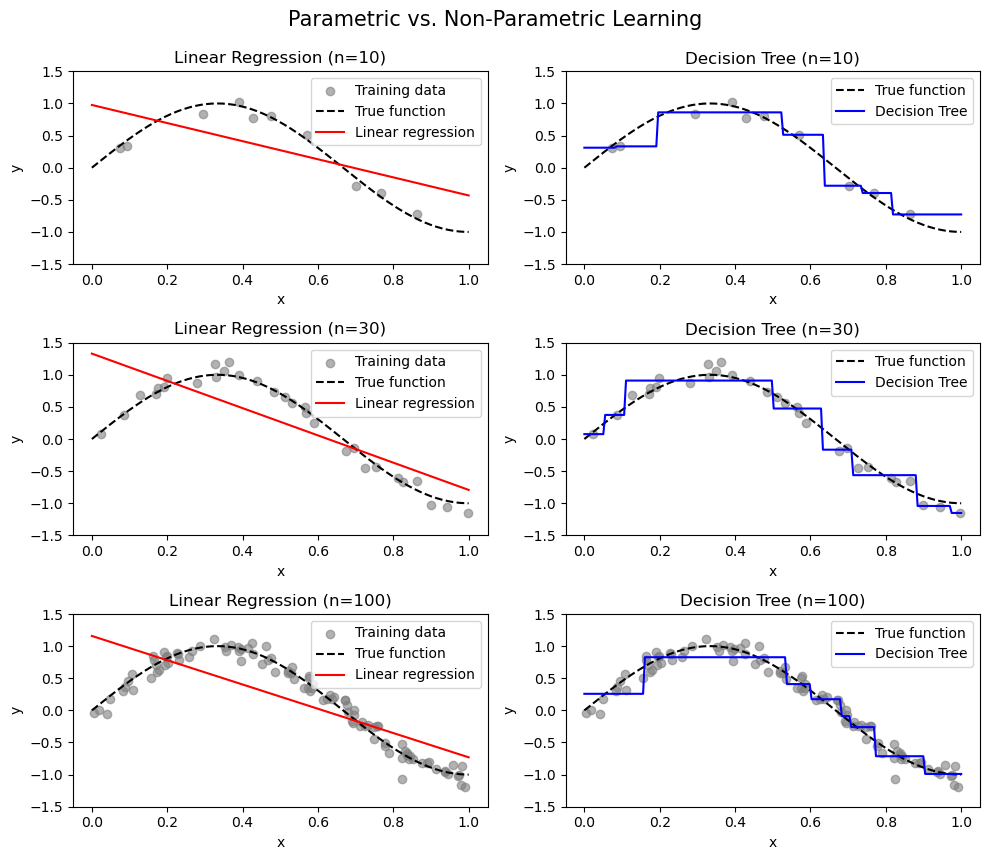

In [4]:
# -----------------------------
# 2. Plot comparison
# -----------------------------
fig, axes = plt.subplots(len(sample_sizes), 2, figsize=(10, 9))
fig.suptitle("Parametric vs. Non-Parametric Learning", fontsize=15, y=0.95)

for i, n in enumerate(sample_sizes):
    # Generate data
    x_train = rng.random(n).reshape(-1, 1)
    y_train = true_function(x_train) + rng.normal(0, 0.1, size=(n, 1))
    
    # Fit models
    lin_reg = LinearRegression().fit(x_train, y_train)
    tree_reg = DecisionTreeRegressor(max_depth=3, random_state=0).fit(x_train, y_train)
    
    # Predictions
    y_pred_lin = lin_reg.predict(x_test)
    y_pred_tree = tree_reg.predict(x_test)
    
    # --- Plot linear regression (parametric) ---
    axes[i, 0].scatter(x_train, y_train, color="gray", alpha=0.6, label="Training data")
    axes[i, 0].plot(x_test, y_true, "k--", label="True function")
    axes[i, 0].plot(x_test, y_pred_lin, "r", label="Linear regression")
    axes[i, 0].set_title(f"Linear Regression (n={n})")
    axes[i, 0].set_ylim(-1.5, 1.5)
    axes[i, 0].legend(loc="upper right")
    
    # --- Plot decision tree (non-parametric) ---
    axes[i, 1].scatter(x_train, y_train, color="gray", alpha=0.6)
    axes[i, 1].plot(x_test, y_true, "k--", label="True function")
    axes[i, 1].plot(x_test, y_pred_tree, "b", label="Decision Tree")
    axes[i, 1].set_title(f"Decision Tree (n={n})")
    axes[i, 1].set_ylim(-1.5, 1.5)
    axes[i, 1].legend(loc="upper right")

for ax in axes.flat:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space at top for the suptitle
plt.show()